<a href="https://colab.research.google.com/github/Terry-data-analyst/Python-data-analytics/blob/main/Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Name:**  ***Omondi Terry Wawuye***

**Admission no:** ***26/04122***

 **Date:** ***16th July, 2026***

 **Project Description:** ***This project analyzes a sales dataset using python to identify business insights and build a predictive model. The goal is to demonstrate the complete data analysis process and findings in a clear and business-friendly manner.***

# **1. Environment setup**

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)

# **2. Load and Inspect dataset**

In [29]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/My Drive/Colab Notebooks/'
capstone_data = pd.read_csv(path + 'Capstone_Project_data.csv')
display(capstone_data.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,date,region,product_category,units_sold,unit_price,revenue,discount_pct
0,1/1/2022,East,Electronics,132,486.59,64275.21,0.073
1,1/1/2022,West,Electronics,151,107.96,16305.57,0.120
2,1/2/2022,North,Electronics,260,352.29,91698.29,0.006
3,1/3/2022,East,Electronics,167,111.12,18485.12,0.232
4,1/4/2022,East,Electronics,147,237.70,34916.14,NaN


In [30]:
#Confirming rows and columns
capstone_data.shape

(1200, 7)

In [31]:
# Checking dtype
capstone_data.dtypes

,0
date,object
region,object
product_category,object
units_sold,int64
unit_price,float64
revenue,float64
discount_pct,float64


In [32]:
#finding missing data
capstone_data.isnull().sum()

,0
date,0
region,0
product_category,0
units_sold,0
unit_price,0
revenue,0
discount_pct,98


This data represents different categories of products and the specific number of units sold, there prices, revenue and their discount percentages

# **3. Data cleaning and transformation**

**task 1: filling missing discount_pct**

In [33]:
mediun_discount = capstone_data['discount_pct'].median()
capstone_data['discount_pct']=capstone_data['discount_pct'].fillna(mediun_discount)
capstone_data.head()

,date,region,product_category,units_sold,unit_price,revenue,discount_pct
0,1/1/2022,East,Electronics,132,486.59,64275.21,0.0730
1,1/1/2022,West,Electronics,151,107.96,16305.57,0.1200
2,1/2/2022,North,Electronics,260,352.29,91698.29,0.0060
3,1/3/2022,East,Electronics,167,111.12,18485.12,0.2320
4,1/4/2022,East,Electronics,147,237.70,34916.14,0.1485


**task 2: Parse dates and extract year/months**

In [34]:
capstone_data['date'] = pd.to_datetime(capstone_data['date'])
capstone_data['year'] = capstone_data['date'].dt.year
capstone_data['month'] = capstone_data['date'].dt.month
capstone_data.head()

,date,region,product_category,units_sold,unit_price,revenue,discount_pct,year,month
0,2022-01-01,East,Electronics,132,486.59,64275.21,0.0730,2022,1
1,2022-01-01,West,Electronics,151,107.96,16305.57,0.1200,2022,1
2,2022-01-02,North,Electronics,260,352.29,91698.29,0.0060,2022,1
3,2022-01-03,East,Electronics,167,111.12,18485.12,0.2320,2022,1
4,2022-01-04,East,Electronics,147,237.70,34916.14,0.1485,2022,1


**task 3: Derive net revenue**

In [35]:
capstone_data['net_revenue'] = capstone_data['revenue'] * (1-capstone_data['discount_pct'])
capstone_data.head()

,date,region,product_category,units_sold,unit_price,revenue,discount_pct,year,month,net_revenue
0,2022-01-01,East,Electronics,132,486.59,64275.21,0.0730,2022,1,59583.11967
1,2022-01-01,West,Electronics,151,107.96,16305.57,0.1200,2022,1,14348.90160
2,2022-01-02,North,Electronics,260,352.29,91698.29,0.0060,2022,1,91148.10026
3,2022-01-03,East,Electronics,167,111.12,18485.12,0.2320,2022,1,14196.57216
4,2022-01-04,East,Electronics,147,237.70,34916.14,0.1485,2022,1,29731.09321


**task 4: One-hot encode categorical columns**

In [36]:
capstone_data_encoded = pd.get_dummies(capstone_data, columns=['region', 'product_category'], drop_first=True)
capstone_data_encoded.head()

,date,units_sold,unit_price,revenue,discount_pct,year,month,net_revenue,region_North,region_South,region_West,product_category_Electronics,product_category_Food,product_category_Home
0,2022-01-01,132,486.59,64275.21,0.0730,2022,1,59583.11967,False,False,False,True,False,False
1,2022-01-01,151,107.96,16305.57,0.1200,2022,1,14348.90160,False,False,True,True,False,False
2,2022-01-02,260,352.29,91698.29,0.0060,2022,1,91148.10026,True,False,False,True,False,False
3,2022-01-03,167,111.12,18485.12,0.2320,2022,1,14196.57216,False,False,False,True,False,False
4,2022-01-04,147,237.70,34916.14,0.1485,2022,1,29731.09321,False,False,False,True,False,False


**Checking again**

In [37]:
capstone_data.isnull().sum()

,0
date,0
region,0
product_category,0
units_sold,0
unit_price,0
revenue,0
discount_pct,0
year,0
month,0
net_revenue,0


The nulls have been resolved

# **4. Data visualization: 5 required charts**

**chart 1: Line chart**

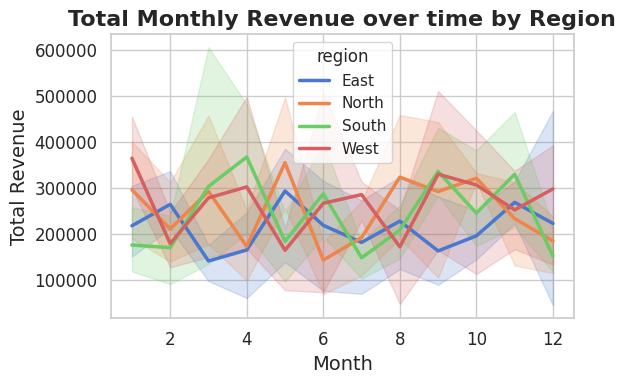

In [38]:
monthly_revenue_by_region = capstone_data.groupby(['year', 'month', 'region'])['revenue'].sum().reset_index()
# sort them chronologically
monthly_revenue_by_region = monthly_revenue_by_region.sort_values('month')
sns.set_theme(style='whitegrid',palette='muted')
plt.figure(figsize=(6, 4))
sns.lineplot(data=monthly_revenue_by_region, x='month', y='revenue', hue='region', linewidth=2.5)
plt.title('Total Monthly Revenue over time by Region', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Total Revenue', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()



Observations: Revenue changes from month to month across all 4 regions showing that sales are not constant throughout the year. No single region consistently has the highest revenue, showing that performance varies over time.

**chart 2: Bar chart- Average units sold per category**

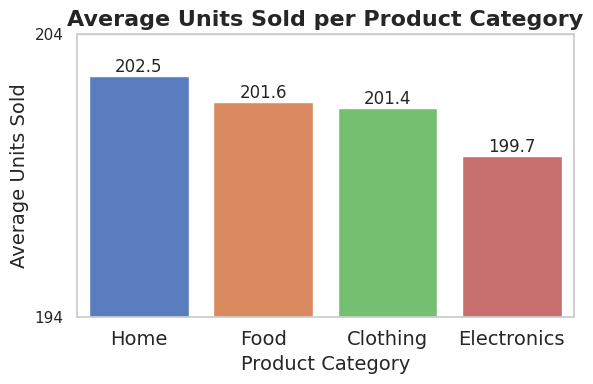

In [39]:
average_units_sold_by_category = capstone_data.groupby('product_category')['units_sold'].mean().reset_index()
average_units_sold_by_category = average_units_sold_by_category.sort_values('units_sold', ascending=False)
plt.figure(figsize=(6, 4))
sns.set_theme(style='whitegrid', palette= 'muted')
x=sns.barplot(data=average_units_sold_by_category, x='product_category', y='units_sold', hue='product_category')
for container in x.containers:
    x.bar_label(container, fmt='%.1f')
plt.title('Average Units Sold per Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Average Units Sold', fontsize=14)
plt.xticks(fontsize=14)
plt.ylim(201.5, 203)
plt.yticks(range(int(average_units_sold_by_category['units_sold'].min())- 5, int(average_units_sold_by_category['units_sold'].max())+ 5 , 10))
plt.tight_layout()
plt.show()

Observation: The average units sold are very similar across all product categories. Home products have the highest average sales, while electronics have the lowest, though the difference is small.

**chart 3: Box plots- Revenue distribution by region**

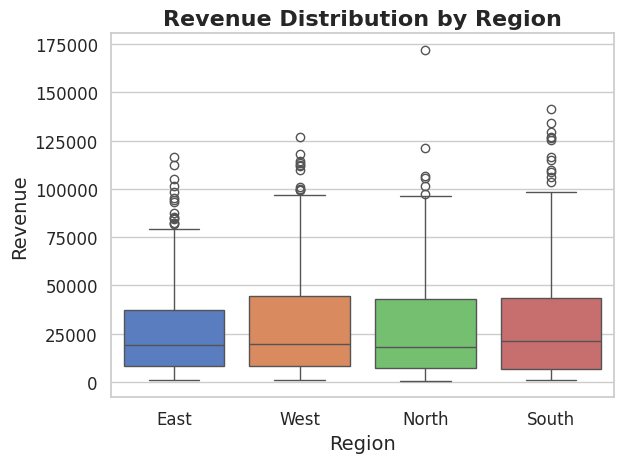

In [40]:
sns.boxplot(data=capstone_data, x='region', y='revenue', hue='region')
plt.title('Revenue Distribution by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=14)
plt.ylabel('Revenue', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.set_theme(style='whitegrid',palette='muted')
plt.tight_layout()
plt.show()


Observation: Revenue is distributed similarly across all regions, which each region showing several high level outliers. this shows that while most sales are within a similar range, occasional transactions generate significantly higher revenue.

**chart 4: Scatter plot- Units_sold vs net revenue with a regression trend line**

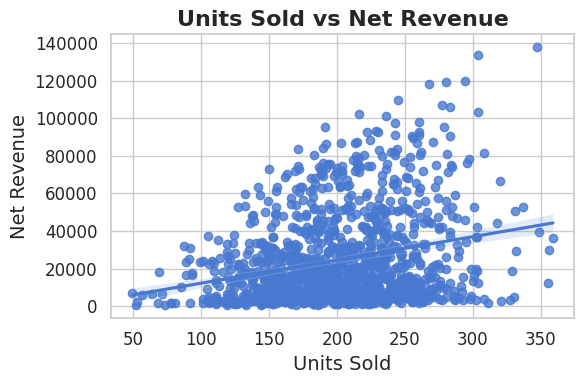

In [41]:
sns.set_theme(style='whitegrid',palette='muted')
plt.figure(figsize=(6, 4))
sns.regplot(data=capstone_data, x='units_sold', y='net_revenue')
plt.title('Units Sold vs Net Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Units Sold', fontsize=14)
plt.ylabel('Net Revenue', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

Observation: There is a positive relationship between units sold and net revenue, hence revenue increases the more units are sold but the wide spred of points suggests that other factors such as unit price and discount percentage also influence revenue.

**chart 5: Heat map- correlation matrixof all numeric features**

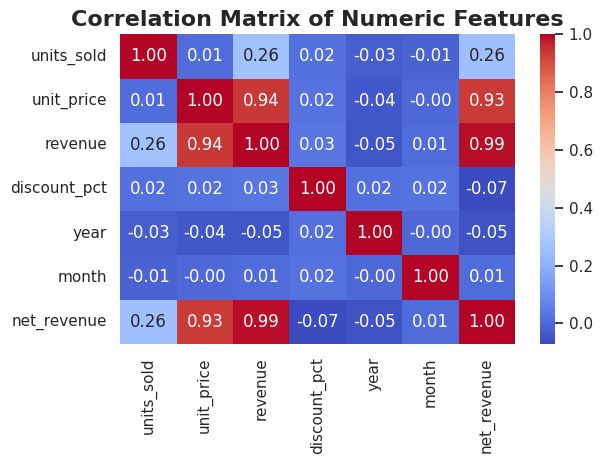

In [42]:
corr_matrix = capstone_data.select_dtypes(include='number').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold')
sns.set_theme(style='whitegrid',palette='muted')
plt.tight_layout()
plt.show()

Observation: Revenue has a strong positive correlation with both unit price and met revenue, while units sold has a weaker positive relationship. Discount percentage shows little correlation with the other variables showing it has minimal impact to this dataset

# **5. Build a linear regression model**

In [43]:
# Predicting net revenue
features=['units_sold','unit_price','discount_pct','year','month']
X=capstone_data[features]
y=capstone_data['revenue']


In [44]:
# Split train and evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model= LinearRegression()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

In [45]:
# Print all evaluation metrix:
print(f'R2: {r2_score(y_test, y_pred):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'RMSE: {mean_squared_error(y_test, y_pred)**0.5:.2f}')


R2: 0.9564
MAE: 3971.72
RMSE: 5829.52


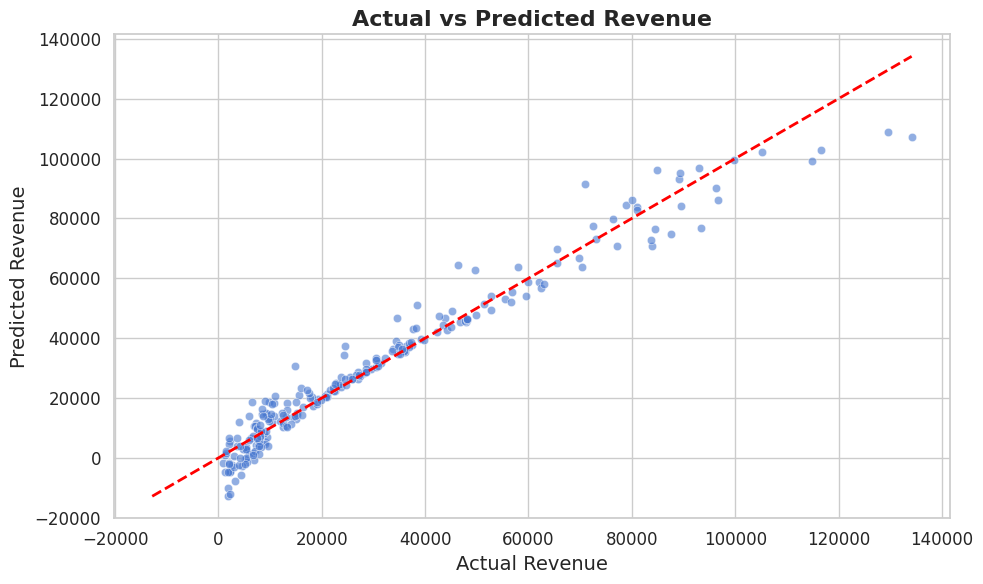

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha= 0.6)
max_value = max(max(y_test), max(y_pred))
min_value = min(min(y_test), min(y_pred))
plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Revenue', fontsize=14)
plt.ylabel('Predicted Revenue', fontsize=14)
plt.title('Actual vs Predicted Revenue', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.set_theme(style='whitegrid',palette='muted')
plt.tight_layout()
plt.show()


Bonus challenge

In [47]:
print('Bonus Challenge: Model comparison(R2 Scores)')
from sklearn.linear_model import Ridge, Lasso
#Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred= ridge_model.predict(X_test)
ridge_r2=r2_score(y_test, ridge_pred)
print(f'Ridge R2 Score: {ridge_r2:.4f}')
# Lasso Regression
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
lasso_pred=lasso_model.predict(X_test)
lasso_r2=r2_score(y_test, lasso_pred)
print(f'Lasso R2 Score: {lasso_r2:.4f}')

Bonus Challenge: Model comparison(R2 Scores)
Ridge R2 Score: 0.9564
Lasso R2 Score: 0.9564


# **6. Write the analysis report**

# Overview
This project analyzed a synthetic sales dataset with 1,200 records and seven variables: date, region, product category, units sold, unit price, revenue, and discount percentage. The dataset represents sales transactions across various regions and product categories over time. The goal was to identify sales patterns, extract key business insights using data visualization, and develop a linear regression model to predict revenue based on important sales variables.

# Key Findings



The line chart demonstrated that monthly revenue varied throughout the year across all regions. No single region consistently outperformed the others, suggesting that sales performance fluctuates over time and may be influenced by seasonal factors.

The bar chart indicates that average units sold were quite similar across product categories. Home products had the highest average units sold, while Electronics had the lowest. However, the differences were small, indicating steady customer demand.

The box plot reveals that all regions had similar revenue distributions, with several high-value outliers. This suggests that while most sales follow a common trend, there are occasional transactions that yield unusually high revenue.

The scatter plot and correlation heatmap shows a strong link between unit price and revenue. Units sold had a weaker positive relationship with revenue. Revenue and net revenue were nearly perfectly correlated, showing they move closely together.

# Model Performance

The linear regression model performed well, achieving an R² score of 0.9564. This means it explained about 95.6% of the changes in revenue. The Mean Absolute Error (MAE) was 3,971.72, indicating that the model’s predictions were off by about 3,972 units from the actual revenue on average. The Root Mean Squared Error (RMSE) was 5,829.52, suggesting that larger prediction errors were relatively uncommon. Overall, these results show that the model gives reliable revenue predictions.

#Limitations

The dataset used in this project is synthetic, meaning it was made for learning rather than gathered from real businesses. Actual sales data would likely contain more unexpected patterns, missing values, and human errors.

Also, real business performance is influenced by many outside factors like competition, promotions, customer preferences, and economic conditions. Since these factors are not included in the dataset, the findings may not fully represent real-world sales performance.

# Recommendations

The business should continue monitoring regional sales trends throughout the year to identify seasonal opportunities and adjust marketing or inventory strategies as needed.

Since unit price has a strong effect on revenue, the company should regularly review its pricing strategy to maintain competitive prices. Analyzing real sales data could also enhance the accuracy of future prediction models and lead to better business choices.

# *Reflection Questions*

1. The median was used because it is less affected by extremely high or low discount values. if the discount percentages were evenly distributed with no significant outliers, the mean  would be a better choice because it uses all the data values. Skewness matters because highly skewed data can pull the mean away from the typical value, making the imputed values less representative.
2. According to the correlation heatmap, revenue(0.99) and unit price(0.93)are the most strongly correlated with net revenue. These values have the greatest influence over revenue.
3. An R2 score of 0.85 means the model explains 85% of the target variable. The remaining 15% represents factors that the model cannot explain like customer behaviour, market changes,  pricing decisions or other factors that were not included in the dataset.
4. Real sales would likely contain more missing values, duplicates, data entry errors, duplicate records. Basically human error. as a result, more time would be spent cleaning, validating, correcting and standardising the data before analysis.
5. Using the function avoids creating duplicate information that could confuse the regression model. It treats one region as the refference group, and the other regions are compared against it helping the model make more accurate predictions.